In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
print(df.dtypes)
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)


total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:

print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())


Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [4]:
import seaborn as sns
tips = sns.load_dataset('tips')
numerical_cols = tips.select_dtypes(include=['number']).columns.tolist()
categorical_cols = tips.select_dtypes(include=['category', 'object']).columns.tolist()
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
tip_mean = tips['tip'].mean()
print(f"\nMean of 'tip': {tip_mean:.2f}")
sex_counts = tips['sex'].value_counts()
print('\nValue counts of column "sex":\n', sex_counts)


Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']

Mean of 'tip': 3.00

Value counts of column "sex":
 sex
Male      157
Female     87
Name: count, dtype: int64


In [5]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))


Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


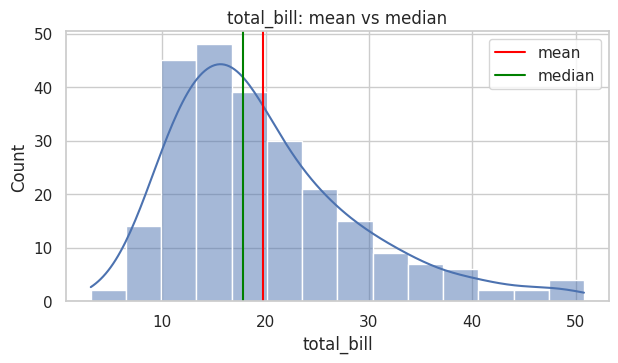

In [6]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()



Mean: 3.00
Median: 2.90
Mode: 2.00

Is mean > median? True (Indicates a right-skewed distribution)


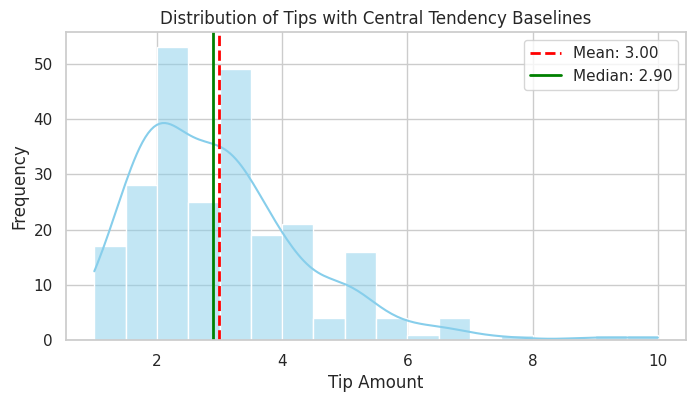

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
tip = df['tip']
mean_val = tip.mean()
median_val = tip.median()
mode_val = tip.mode()[0]
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Mode: {mode_val:.2f}")
is_right_skewed = mean_val > median_val
print(f"\nIs mean > median? {is_right_skewed} (Indicates a right-skewed distribution)")
plt.figure(figsize=(8, 4))
sns.histplot(tip, kde=True, color='skyblue')
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.title('Distribution of Tips with Central Tendency Baselines')
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [8]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))


Range : 47.74
Var   : 79.25
Std   : 8.9


In [9]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')


Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [10]:
import numpy as np
import pandas as pd
tip = df['tip']

data_range = tip.max() - tip.min()
variance_val = tip.var()
std_val = tip.std()

print(f"Range: {data_range:.2f}")
print(f"Variance: {variance_val:.4f}")
print(f"Standard Deviation: {std_val:.4f}")
q1 = tip.quantile(0.25)
q3 = tip.quantile(0.75)
iqr = q3 - q1

print(f"\nQ1 (25th percentile): {q1:.2f}")
print(f"Q3 (75th percentile): {q3:.2f}")
print(f"IQR (Interquartile Range): {iqr:.2f}")


Range: 9.00
Variance: 1.9145
Standard Deviation: 1.3836

Q1 (25th percentile): 2.00
Q3 (75th percentile): 3.56
IQR (Interquartile Range): 1.56


In [11]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


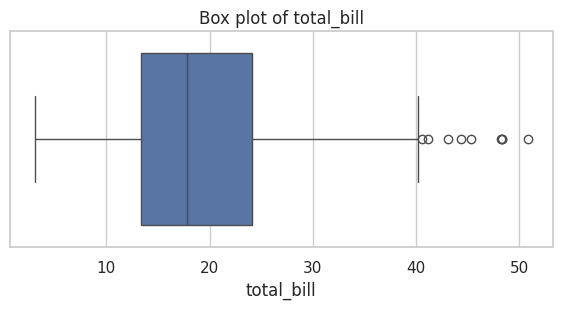

In [12]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()


Five-Number Summary:
 min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.4655
Comment: The distribution is positively skewed (right-skewed). It has a long tail leaning towards higher tip amounts.


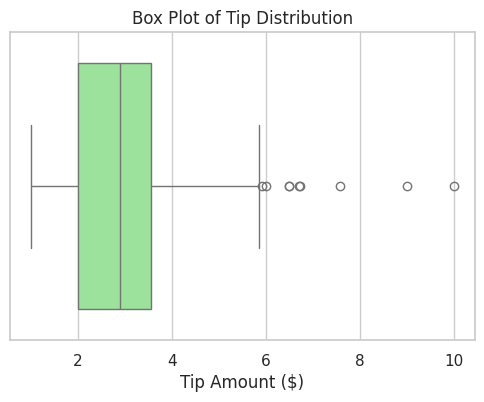

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
tip = df['tip']
five_num_summary = tip.describe().loc[['min', '25%', '50%', '75%', 'max']]
print("Five-Number Summary:\n", five_num_summary)
skew_val = tip.skew()
print(f"\nSkewness: {skew_val:.4f}")
if skew_val > 0:
    print("Comment: The distribution is positively skewed (right-skewed). It has a long tail leaning towards higher tip amounts.")
elif skew_val < 0:
    print("Comment: The distribution is negatively skewed (left-skewed). It has a long tail leaning towards lower tip amounts.")
else:
    print("Comment: The distribution is perfectly symmetric.")
plt.figure(figsize=(6, 4))
sns.boxplot(x=tip, color='lightgreen')
plt.title('Box Plot of Tip Distribution')
plt.xlabel('Tip Amount ($)')
plt.show()


In [14]:
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


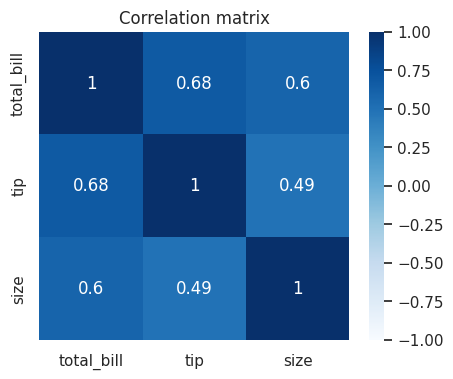

In [15]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()


In [16]:
df.describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Correlation Matrix:
             total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


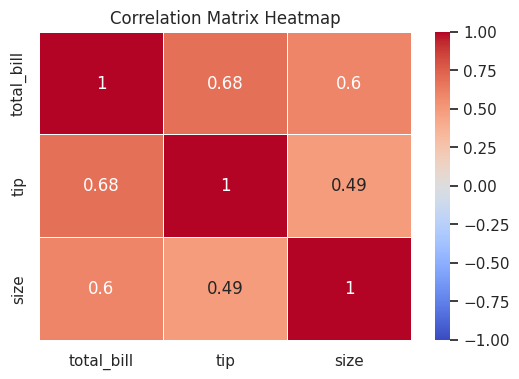


DataFrame Summary Statistics:
         total_bill         tip   sex smoker  day    time        size
count   244.000000  244.000000   244    244  244     244  244.000000
unique         NaN         NaN     2      2    4       2         NaN
top            NaN         NaN  Male     No  Sat  Dinner         NaN
freq           NaN         NaN   157    151   87     176         NaN
mean     19.785943    2.998279   NaN    NaN  NaN     NaN    2.569672
std       8.902412    1.383638   NaN    NaN  NaN     NaN    0.951100
min       3.070000    1.000000   NaN    NaN  NaN     NaN    1.000000
25%      13.347500    2.000000   NaN    NaN  NaN     NaN    2.000000
50%      17.795000    2.900000   NaN    NaN  NaN     NaN    2.000000
75%      24.127500    3.562500   NaN    NaN  NaN     NaN    3.000000
max      50.810000   10.000000   NaN    NaN  NaN     NaN    6.000000


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = df.select_dtypes(include=['number']).corr().round(2)
print("Correlation Matrix:\n", corr_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()
summary_stats = df.describe(include='all')
print('\nDataFrame Summary Statistics:\n', summary_stats)
